Image shape: (128, 128, 3)
Mask shape : (128, 128)
Removal ratio: 0.8997802734375
Lab empty known max diff: 0
Lab copy known max diff: 0
RGB copy known max diff: 0

Lab source ranges:
L 0 207
a 110 187
b 120 186

Lab reconstructed ranges:
L 0 207
a 0 187
b 0 186


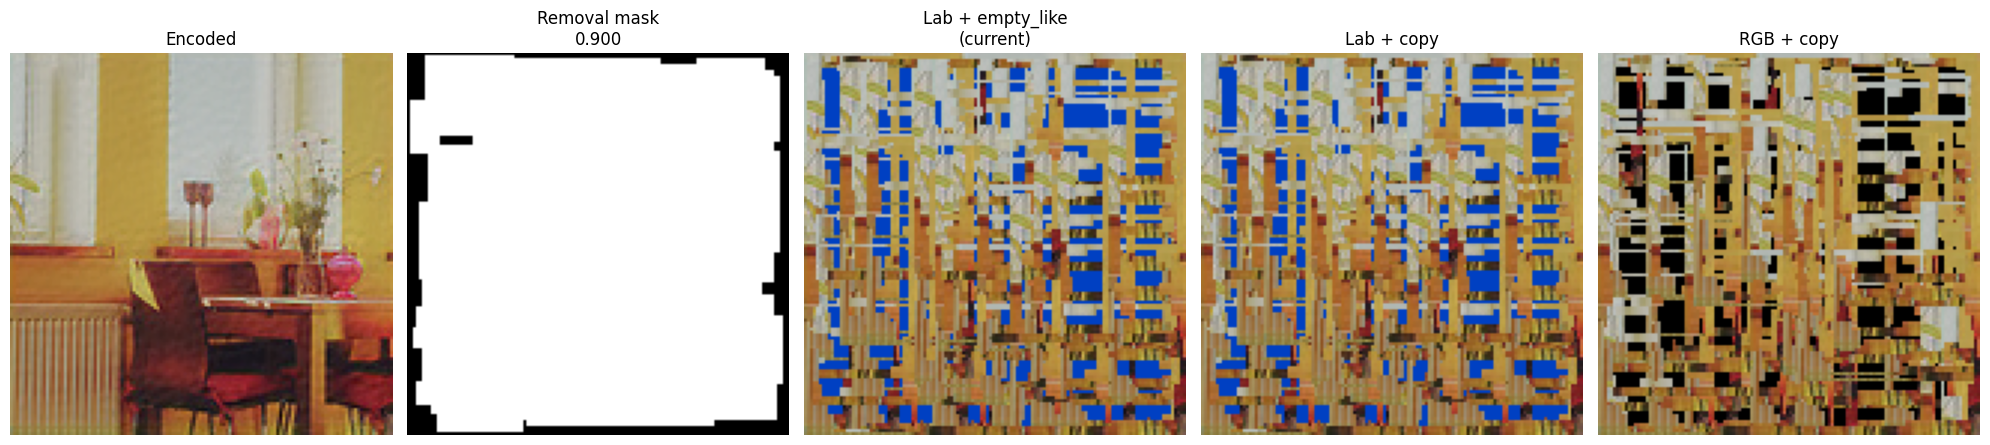

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from pathlib import Path


# ============================================================
# 1. Set paths
# ============================================================

debug_dir = Path(
    "sweep_results/debug/"
    "M_3k_gaussian_blur_A_shiftmap"
)

ratio = "0.900"

encoded_path = debug_dir / f"encoded_{ratio}.png"
mask_path = debug_dir / f"removal_mask_{ratio}.png"


# ============================================================
# 2. Load encoded image + removal mask
# ============================================================

rgb = np.array(
    Image.open(encoded_path).convert("RGB")
)

mask_img = np.array(
    Image.open(mask_path).convert("L")
)

# Our convention:
# True = missing / must be reconstructed
removal = mask_img > 127

# OpenCV xphoto convention:
# 255 = valid
#   0 = reconstruct
valid_mask = (
    (~removal).astype(np.uint8) * 255
)

print("Image shape:", rgb.shape)
print("Mask shape :", removal.shape)
print("Removal ratio:", removal.mean())


# ============================================================
# Helper: strict blending
# ============================================================

def strict_blend(original, reconstructed, removal):
    """
    Keep all known pixels exactly unchanged.
    Only use reconstructed pixels inside the removal mask.
    """
    output = original.copy()
    output[removal] = reconstructed[removal]
    return output


# ============================================================
# 3A. CURRENT implementation:
#     Lab + np.empty_like
# ============================================================

lab = cv2.cvtColor(
    rgb,
    cv2.COLOR_RGB2LAB,
)

masked_lab = lab.copy()

masked_lab[removal] = np.array(
    [0, 128, 128],
    dtype=np.uint8,
)

dst_lab_empty = np.empty_like(
    masked_lab
)

cv2.xphoto.inpaint(
    masked_lab,
    valid_mask,
    dst_lab_empty,
    cv2.xphoto.INPAINT_SHIFTMAP,
)

rgb_lab_empty = cv2.cvtColor(
    dst_lab_empty,
    cv2.COLOR_LAB2RGB,
)

out_lab_empty = strict_blend(
    rgb,
    rgb_lab_empty,
    removal,
)


# ============================================================
# 3B. Safer Lab implementation:
#     Lab + masked_lab.copy()
# ============================================================

dst_lab_copy = masked_lab.copy()

cv2.xphoto.inpaint(
    masked_lab,
    valid_mask,
    dst_lab_copy,
    cv2.xphoto.INPAINT_SHIFTMAP,
)

rgb_lab_copy = cv2.cvtColor(
    dst_lab_copy,
    cv2.COLOR_LAB2RGB,
)

out_lab_copy = strict_blend(
    rgb,
    rgb_lab_copy,
    removal,
)


# ============================================================
# 3C. RGB experiment:
#     RGB directly + masked_rgb.copy()
#
# This is only a diagnostic experiment.
# OpenCV recommends a Lab-like space for ShiftMap.
# ============================================================

masked_rgb = rgb.copy()

# Remove ground truth from missing region
masked_rgb[removal] = np.array(
    [0, 0, 0],
    dtype=np.uint8,
)

dst_rgb = masked_rgb.copy()

cv2.xphoto.inpaint(
    masked_rgb,
    valid_mask,
    dst_rgb,
    cv2.xphoto.INPAINT_SHIFTMAP,
)

out_rgb = strict_blend(
    rgb,
    dst_rgb,
    removal,
)


# ============================================================
# 4. Check whether known pixels changed
# ============================================================

known = ~removal

print(
    "Lab empty known max diff:",
    np.abs(
        out_lab_empty.astype(np.int16)[known]
        - rgb.astype(np.int16)[known]
    ).max()
)

print(
    "Lab copy known max diff:",
    np.abs(
        out_lab_copy.astype(np.int16)[known]
        - rgb.astype(np.int16)[known]
    ).max()
)

print(
    "RGB copy known max diff:",
    np.abs(
        out_rgb.astype(np.int16)[known]
        - rgb.astype(np.int16)[known]
    ).max()
)


# ============================================================
# 5. Inspect Lab output ranges
# ============================================================

print("\nLab source ranges:")
for i, channel in enumerate(["L", "a", "b"]):
    print(
        channel,
        masked_lab[..., i].min(),
        masked_lab[..., i].max(),
    )

print("\nLab reconstructed ranges:")
for i, channel in enumerate(["L", "a", "b"]):
    print(
        channel,
        dst_lab_copy[..., i].min(),
        dst_lab_copy[..., i].max(),
    )


# ============================================================
# 6. Visual comparison
# ============================================================

fig, axes = plt.subplots(
    1,
    5,
    figsize=(20, 5),
)

axes[0].imshow(rgb)
axes[0].set_title("Encoded")

axes[1].imshow(
    removal,
    cmap="gray",
)
axes[1].set_title(
    f"Removal mask\n{removal.mean():.3f}"
)

axes[2].imshow(out_lab_empty)
axes[2].set_title(
    "Lab + empty_like\n(current)"
)

axes[3].imshow(out_lab_copy)
axes[3].set_title(
    "Lab + copy"
)

axes[4].imshow(out_rgb)
axes[4].set_title(
    "RGB + copy"
)

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

 ratio |  actual |  Lab PSNR |  RGB PSNR | bad chroma | fraction
------------------------------------------------------------------------
 0.500 |  0.4995 |    16.303 |    17.721 |          0 |   0.000%
 0.600 |  0.5999 |    16.305 |    16.914 |          0 |   0.000%
 0.700 |  0.7000 |    15.322 |    15.209 |          2 |   0.017%
 0.800 |  0.7997 |    14.042 |    13.234 |        476 |   3.633%
 0.900 |  0.8998 |    11.559 |    10.852 |       2417 |  16.395%

0.500: known diff Lab=0, RGB=0
0.600: known diff Lab=0, RGB=0
0.700: known diff Lab=0, RGB=0
0.800: known diff Lab=0, RGB=0
0.900: known diff Lab=0, RGB=0


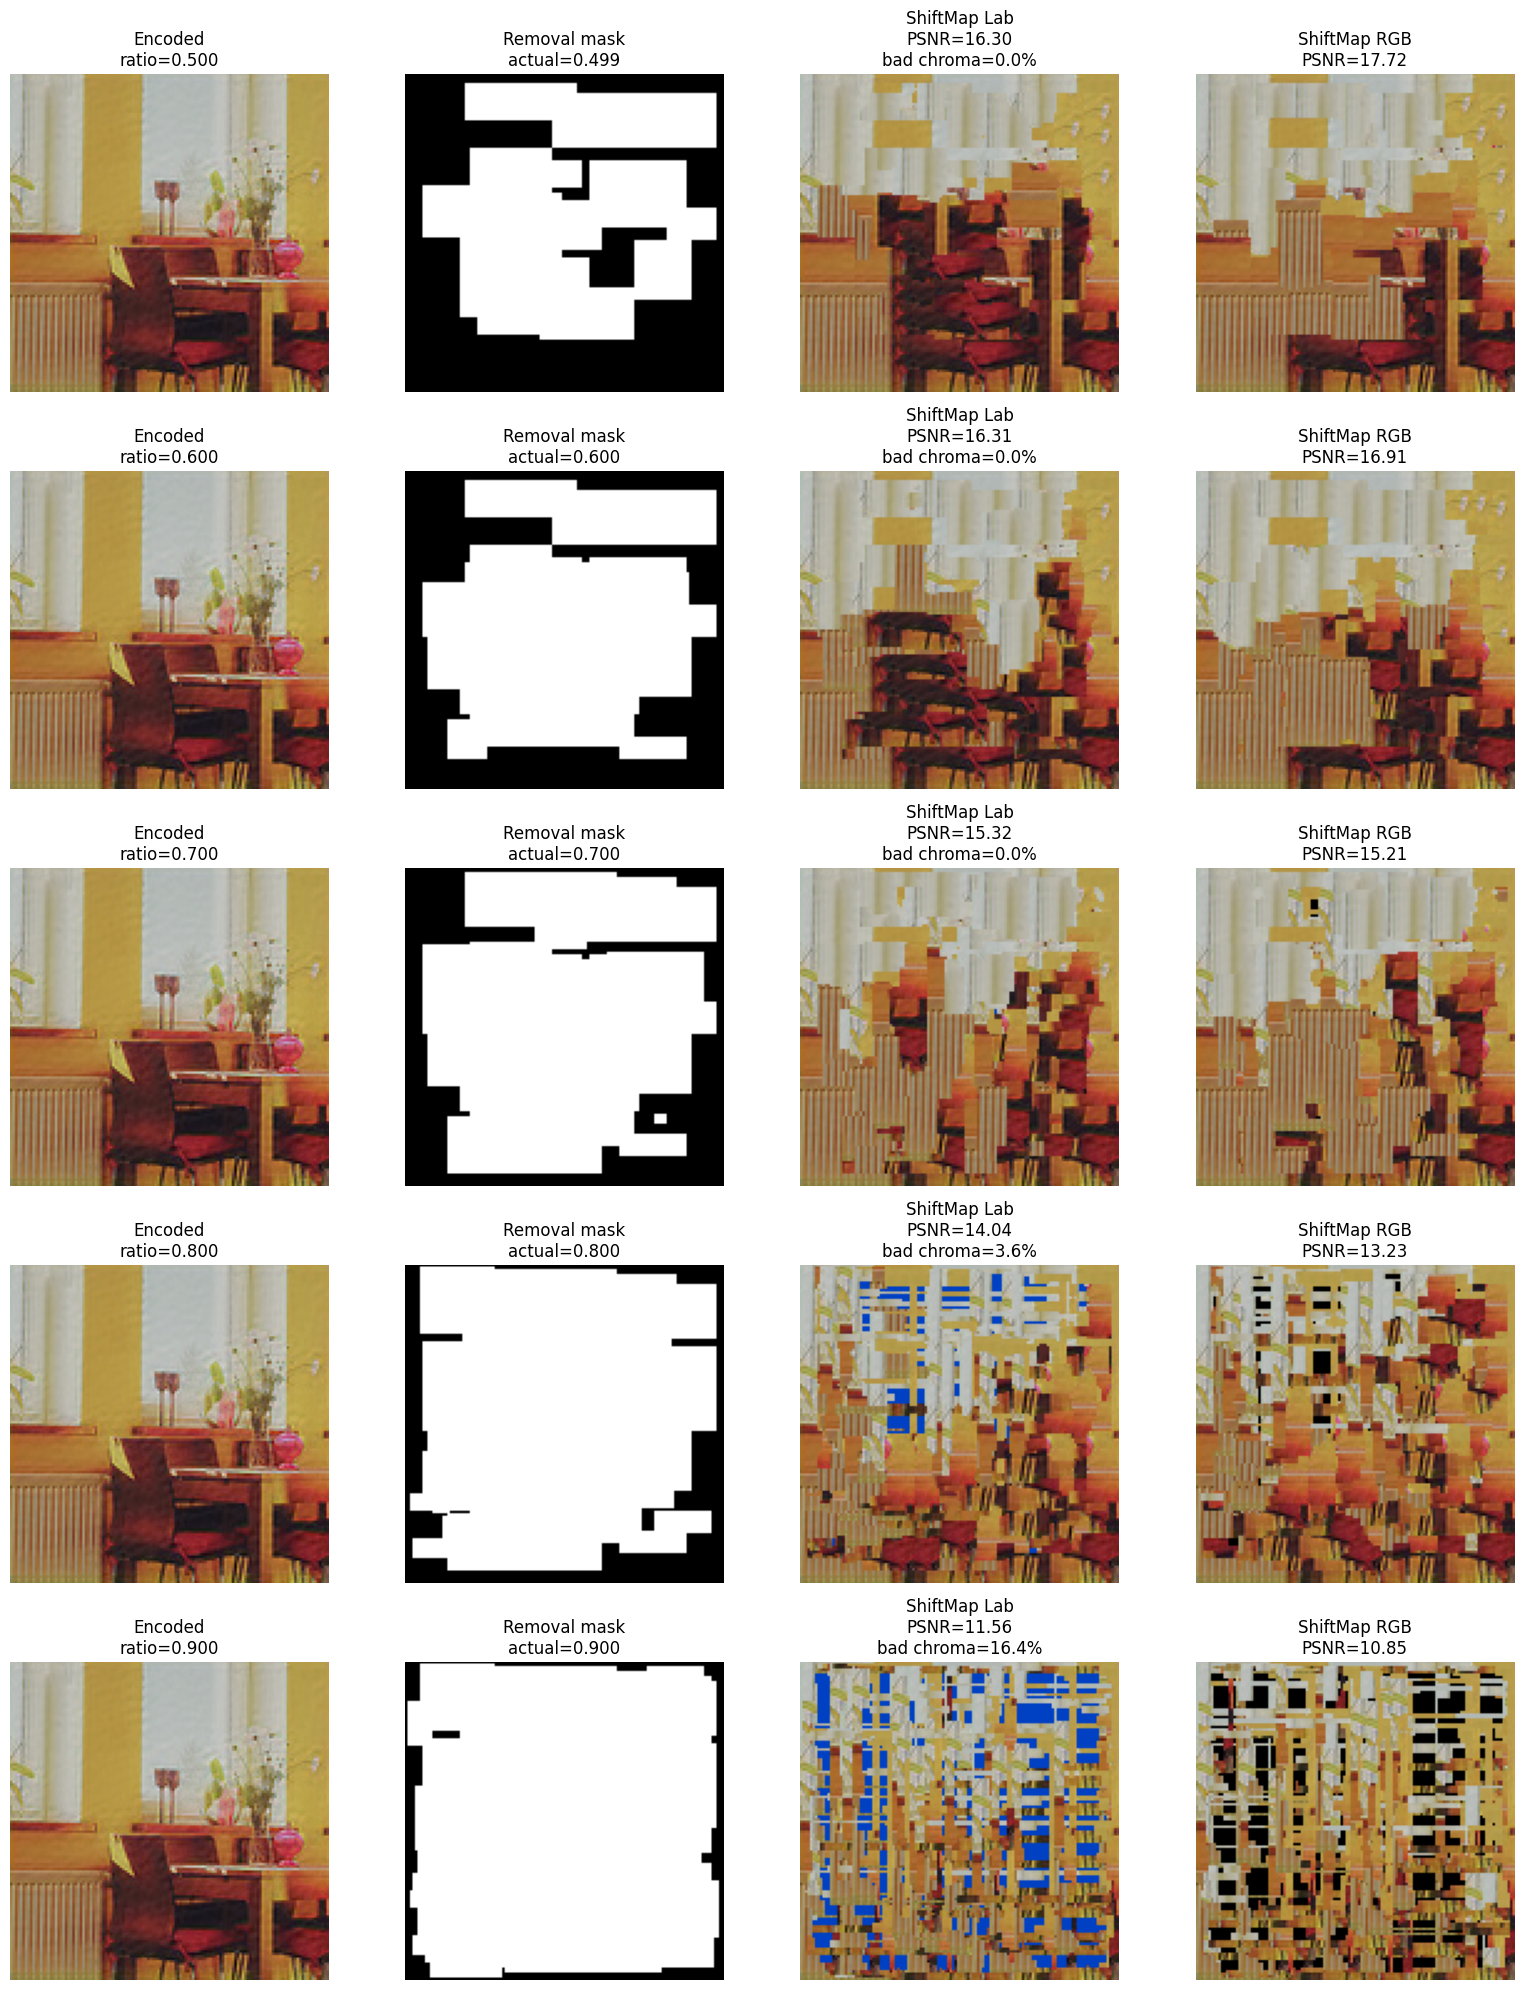

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from pathlib import Path


# ============================================================
# CONFIG
# ============================================================

debug_dir = Path(
    "sweep_results/debug/"
    "M_3k_gaussian_blur_A_shiftmap"
)

ratios = [
    "0.500",
    "0.600",
    "0.700",
    "0.800",
    "0.900",
]


# ============================================================
# HELPERS
# ============================================================

def strict_blend(original, reconstructed, removal):
    """
    Keep known pixels exactly unchanged.
    Only replace pixels inside the removal mask.
    """
    output = original.copy()
    output[removal] = reconstructed[removal]
    return output


def compute_psnr_np(a, b):
    """
    Simple RGB PSNR for uint8 images.
    """
    a = a.astype(np.float32)
    b = b.astype(np.float32)

    mse = np.mean((a - b) ** 2)

    if mse == 0:
        return float("inf")

    return 20 * np.log10(
        255.0 / np.sqrt(mse)
    )


def run_shiftmap_lab(rgb, removal):
    """
    ShiftMap in OpenCV uint8 Lab space.
    """

    valid_mask = (
        (~removal).astype(np.uint8)
        * 255
    )

    lab = cv2.cvtColor(
        rgb,
        cv2.COLOR_RGB2LAB,
    )

    masked_lab = lab.copy()

    # Neutral black:
    # L=0, a=128, b=128
    masked_lab[removal] = np.array(
        [0, 128, 128],
        dtype=np.uint8,
    )

    # Safer than np.empty_like
    reconstructed_lab = masked_lab.copy()

    cv2.xphoto.inpaint(
        masked_lab,
        valid_mask,
        reconstructed_lab,
        cv2.xphoto.INPAINT_SHIFTMAP,
    )

    reconstructed_rgb = cv2.cvtColor(
        reconstructed_lab,
        cv2.COLOR_LAB2RGB,
    )

    output = strict_blend(
        rgb,
        reconstructed_rgb,
        removal,
    )

    return output, reconstructed_lab


def run_shiftmap_rgb(rgb, removal):
    """
    Diagnostic version:
    run ShiftMap directly in RGB.
    """

    valid_mask = (
        (~removal).astype(np.uint8)
        * 255
    )

    masked_rgb = rgb.copy()

    # Erase ground truth.
    masked_rgb[removal] = 0

    reconstructed_rgb = masked_rgb.copy()

    cv2.xphoto.inpaint(
        masked_rgb,
        valid_mask,
        reconstructed_rgb,
        cv2.xphoto.INPAINT_SHIFTMAP,
    )

    output = strict_blend(
        rgb,
        reconstructed_rgb,
        removal,
    )

    return output


# ============================================================
# RUN ALL RATIOS
# ============================================================

all_results = {}

for ratio in ratios:

    encoded_path = (
        debug_dir
        / f"encoded_{ratio}.png"
    )

    mask_path = (
        debug_dir
        / f"removal_mask_{ratio}.png"
    )

    rgb = np.array(
        Image.open(
            encoded_path
        ).convert("RGB")
    )

    mask_img = np.array(
        Image.open(
            mask_path
        ).convert("L")
    )

    removal = (
        mask_img > 127
    )

    # ----------------------------------------
    # Lab version
    # ----------------------------------------

    lab_output, reconstructed_lab = (
        run_shiftmap_lab(
            rgb,
            removal,
        )
    )

    # ----------------------------------------
    # RGB version
    # ----------------------------------------

    rgb_output = (
        run_shiftmap_rgb(
            rgb,
            removal,
        )
    )

    # ----------------------------------------
    # Diagnostics
    # ----------------------------------------

    known = ~removal

    lab_known_diff = np.abs(
        lab_output.astype(np.int16)[known]
        - rgb.astype(np.int16)[known]
    ).max()

    rgb_known_diff = np.abs(
        rgb_output.astype(np.int16)[known]
        - rgb.astype(np.int16)[known]
    ).max()

    # Count suspicious chroma values inside
    # the reconstructed region.
    a_channel = reconstructed_lab[..., 1]
    b_channel = reconstructed_lab[..., 2]

    abnormal_a0 = np.sum(
        (a_channel == 0)
        & removal
    )

    abnormal_b0 = np.sum(
        (b_channel == 0)
        & removal
    )

    abnormal_either = np.sum(
        (
            (a_channel == 0)
            | (b_channel == 0)
        )
        & removal
    )

    missing_pixels = np.sum(
        removal
    )

    abnormal_fraction = (
        abnormal_either
        / missing_pixels
        if missing_pixels > 0
        else 0.0
    )

    all_results[ratio] = {
        "encoded": rgb,
        "mask": removal,
        "lab": lab_output,
        "rgb": rgb_output,

        "removal_ratio": removal.mean(),

        "lab_psnr": compute_psnr_np(
            rgb,
            lab_output,
        ),

        "rgb_psnr": compute_psnr_np(
            rgb,
            rgb_output,
        ),

        "lab_known_diff": lab_known_diff,
        "rgb_known_diff": rgb_known_diff,

        "a_zero": abnormal_a0,
        "b_zero": abnormal_b0,
        "abnormal": abnormal_either,
        "abnormal_fraction": abnormal_fraction,
    }


# ============================================================
# PRINT NUMERICAL SUMMARY
# ============================================================

print(
    f"{'ratio':>6} | "
    f"{'actual':>7} | "
    f"{'Lab PSNR':>9} | "
    f"{'RGB PSNR':>9} | "
    f"{'bad chroma':>10} | "
    f"{'fraction':>8}"
)

print("-" * 72)

for ratio, r in all_results.items():

    print(
        f"{ratio:>6} | "
        f"{r['removal_ratio']:7.4f} | "
        f"{r['lab_psnr']:9.3f} | "
        f"{r['rgb_psnr']:9.3f} | "
        f"{r['abnormal']:10d} | "
        f"{r['abnormal_fraction']:8.3%}"
    )

print()

for ratio, r in all_results.items():

    print(
        f"{ratio}: "
        f"known diff "
        f"Lab={r['lab_known_diff']}, "
        f"RGB={r['rgb_known_diff']}"
    )


# ============================================================
# VISUAL COMPARISON
# ============================================================

fig, axes = plt.subplots(
    len(ratios),
    4,
    figsize=(16, 4 * len(ratios)),
)

for row, ratio in enumerate(ratios):

    r = all_results[ratio]

    axes[row, 0].imshow(
        r["encoded"]
    )

    axes[row, 0].set_title(
        f"Encoded\nratio={ratio}"
    )

    axes[row, 1].imshow(
        r["mask"],
        cmap="gray",
    )

    axes[row, 1].set_title(
        f"Removal mask\n"
        f"actual={r['removal_ratio']:.3f}"
    )

    axes[row, 2].imshow(
        r["lab"]
    )

    axes[row, 2].set_title(
        f"ShiftMap Lab\n"
        f"PSNR={r['lab_psnr']:.2f}\n"
        f"bad chroma={r['abnormal_fraction']:.1%}"
    )

    axes[row, 3].imshow(
        r["rgb"]
    )

    axes[row, 3].set_title(
        f"ShiftMap RGB\n"
        f"PSNR={r['rgb_psnr']:.2f}"
    )

    for col in range(4):
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()